#**Modelo Predictivo - AVISTAMIENTOS DE AVES**


---





# Carga del dataset final

In [30]:
!pip install imblearn

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re, os, unicodedata
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Montar Google Drive para acceder al archivo
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Ruta del archivo en Google Drive
# Asegúrate de que la ruta sea correcta.
DATA_DIR = '/content/drive/MyDrive/Proyectos/Aves'

PATH_INPUT = f'{DATA_DIR}/dataset-2025-definitivo.csv'

# Cargar el archivo CSV en un DataFrame de pandas
try:
    df = pd.read_csv(PATH_INPUT, sep=',', engine='python')
    df_copy = df.copy(deep=True)
    print("Archivo cargado exitosamente.")
    print(df.info())
except FileNotFoundError:
    print(f"Error: El archivo no se encontró en la ruta especificada: {PATH_INPUT}")
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")

Mounted at /content/drive
Archivo cargado exitosamente.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79215 entries, 0 to 79214
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order                          79215 non-null  object 
 1   family                         79215 non-null  object 
 2   genus                          79215 non-null  object 
 3   species                        79215 non-null  object 
 4   individualCount                79215 non-null  int64  
 5   decimalLatitude                79215 non-null  float64
 6   decimalLongitude               79215 non-null  float64
 7   coordinateUncertaintyInMeters  79215 non-null  float64
 8   day                            79215 non-null  int64  
 9   month                          79215 non-null  int64  
 10  timeRange                      79215 non-null  int64  
 11  hour                           79215 non-null  flo

In [32]:
df = df_copy.copy(deep=True)

In [33]:
# Eliminar SPECIES raras
class_counts = df['species'].value_counts()
print(class_counts)

rare_classes = class_counts[class_counts <= 500].index.tolist()
print("Clases raras:", rare_classes)
print("Cantidad de clases raras:", len(rare_classes))

df = df.loc[~df["species"].isin(rare_classes)]

print(df.info())

species
Caracara plancus              1535
Pitangus sulphuratus          1527
Zonotrichia capensis          1467
Furnarius rufus               1357
Mimus saturninus              1340
                              ... 
Leucophaeus pipixcan             1
Anthus brevirostris              1
Sporophila bouvreuil             1
Myiothlypis signata              1
Herpsilochmus atricapillus       1
Name: count, Length: 864, dtype: int64
Clases raras: ['Polioptila dumicola', 'Anas georgica', 'Columba livia', 'Tyrannus melancholicus', 'Chauna torquata', 'Saltator aurantiirostris', 'Coscoroba coscoroba', 'Sporophila caerulescens', 'Himantopus mexicanus', 'Thraupis sayaca', 'Rauenia bonariensis', 'Ciconia maguari', 'Spatula versicolor', 'Netta peposaca', 'Turdus amaurochalinus', 'Sicalis luteola', 'Gallinula chloropus', 'Egretta thula', 'Aramus guarauna', 'Callonetta leucophrys', 'Progne tapera', 'Jacana jacana', 'Syrigma sibilatrix', 'Anas bahamensis', 'Tigrisoma lineatum', 'Hirundo rustica', 'Pod

In [34]:
df.drop(['order', 'family', 'genus'], axis=1, inplace=True)

# Encoding de SPECIES
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

# Encoding de PROVINCIAS
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
categorical_cols = ['provincia_num']

# Create a copy of the categorical column before encoding
df_categorical = df[categorical_cols].copy()

ohe.fit(df_categorical)
encoded_data = ohe.transform(df_categorical)
encoded_df = pd.DataFrame(encoded_data, columns=ohe.get_feature_names_out(categorical_cols), index=df.index) # Preserve original index

# Concatenate the original DataFrame (excluding the original categorical column) with the encoded DataFrame
df = pd.concat([df.drop(columns=categorical_cols), encoded_df], axis=1)

In [35]:
print(df.info())
for columna in df.columns:
    conteo = df[columna].value_counts()
    print(f"\nConteo de valores en la columna '{columna}':")
    print(conteo)

<class 'pandas.core.frame.DataFrame'>
Index: 31377 entries, 0 to 79213
Data columns (total 37 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   species                        31377 non-null  int64  
 1   individualCount                31377 non-null  int64  
 2   decimalLatitude                31377 non-null  float64
 3   decimalLongitude               31377 non-null  float64
 4   coordinateUncertaintyInMeters  31377 non-null  float64
 5   day                            31377 non-null  int64  
 6   month                          31377 non-null  int64  
 7   timeRange                      31377 non-null  int64  
 8   hour                           31377 non-null  float64
 9   hour_cycle                     31377 non-null  float64
 10  day_of_year                    31377 non-null  int64  
 11  elevation_m                    31377 non-null  float64
 12  temp_annual_c                  31377 non-null  floa

# Árboles de Decisión

Imports

In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
from IPython.display import Image
from io import StringIO
from sklearn.model_selection import RandomizedSearchCV, train_test_split
import numpy as np
from sklearn import metrics
from sklearn.metrics import classification_report
import pydotplus
from scipy.stats import randint

Eliminación de columnas y división de datos

In [37]:
dfClf = df.copy()

x = dfClf.drop('species',axis=1)
y = dfClf['species']
xTrain, xTest, yTrain, yTest = train_test_split(x, y, train_size=0.7, random_state=42)

Creamos y entrenamos el árbol con los valores por defecto

In [38]:
# Creamos y entrenamos el árbol
clf = DecisionTreeClassifier(random_state=42, class_weight="balanced")
clf = clf.fit(xTrain, yTrain)

# Información general
print("Número de nodos:", clf.tree_.node_count)
print("Profundidad:", clf.get_depth())

# Comprobamos precisión
yPred = clf.predict(xTest)

print("Accuracy:", metrics.accuracy_score(yTest, yPred))
print("Precision:", metrics.precision_score(yTest, yPred, average='weighted'))
print("F1 Score (macro avg):", metrics.f1_score(yTest, yPred, average='macro'))

Número de nodos: 33013
Profundidad: 40
Accuracy: 0.11759082217973231
Precision: 0.11908271396159302
F1 Score (macro avg): 0.12417621306934133


In [39]:
probabilidad = clf.predict_proba(xTest)

# Obtener las especies con mayor probabilidad para cada registro de test
top_3_species_indices = np.argsort(-probabilidad, axis=1)[:, :3]
top_10_species_indices = np.argsort(-probabilidad, axis=1)[:, :10]

# Mapear los índices a los nombres de las especies y obtener las probabilidades
top_3_species_names = clf.classes_[top_3_species_indices]
top_10_species_names = clf.classes_[top_10_species_indices]
top_3_probabilities = -np.sort(-probabilidad, axis=1)[:, :3]
top_10_probabilities = -np.sort(-probabilidad, axis=1)[:, :10]
acc1 = 0
acc3 = 0
acc10 = 0
sum1 = 0
sum3 = 0
sum10 = 0

for i in range(len(xTest)):
    if yTest.values[i] in top_10_species_names[i]:
        sum10 += 1
        if yTest.values[i] in top_3_species_names[i]:
            sum3 += 1
            if yTest.values[i] == yPred[i]:
                sum1 += 1

acc1 = sum1 / len(xTest)
acc3 = sum3 / len(xTest)
acc10 = sum10 / len(xTest)

print("TOP-K ACCURACY")
print("Top-1: ", acc1)
print("Top-3: ", acc3)
print("Top-10: ", acc10)

TOP-K ACCURACY
Top-1:  0.11759082217973231
Top-3:  0.16146165285744635
Top-10:  0.3270660718079456


## Matriz de confusión

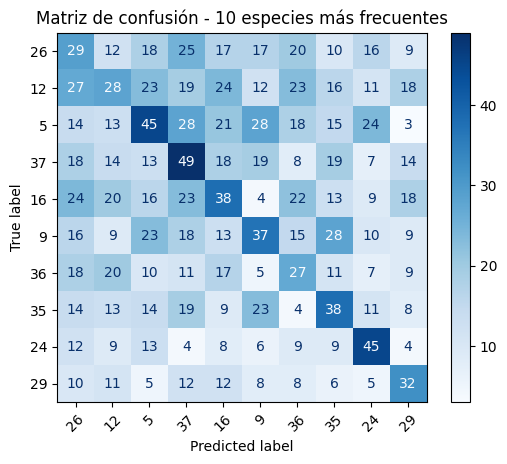

In [40]:
# 📊 Matriz de confusión para las 10 especies más frecuentes

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Seleccionar las 10 especies más comunes en el conjunto de test
top_species = yTest.value_counts().head(10).index

# Crear una máscara para filtrar solo esas especies
mask = yTest.isin(top_species)
yTest_top = yTest[mask]
yPred_top = yPred[mask]

# Calcular la matriz de confusión
cm = confusion_matrix(yTest_top, yPred_top, labels=top_species)

# Mostrar la matriz como gráfico
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_species)
disp.plot(cmap='Blues', xticks_rotation=45)

plt.title("Matriz de confusión - 10 especies más frecuentes")
plt.show()


# Random Forest

Imports

In [41]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint
from io import StringIO
from sklearn.tree import export_graphviz
from sklearn import metrics
from IPython.display import Image
import graphviz
from sklearn.tree import export_graphviz
import pydotplus
import re
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier

Eliminación de columnas y división de datos

In [42]:
dfRf = df.copy()

x = dfRf.drop('species',axis=1)
y = dfRf['species']
xTrain, xTest, yTrain, yTest = train_test_split(x, y, train_size=0.7, random_state=42, stratify=y)

Balanceo de clases

In [43]:
# Separate features (x) and target (y) for SMOTE
x_smote = df.drop('species', axis=1)
y_smote = df['species']

# Apply SMOTE to the training data (assuming xTrain and yTrain are already defined)
smote = SMOTE(random_state=42)
xTrain, yTrain = smote.fit_resample(xTrain, yTrain)

print("Resampled dataset shape %s" % Counter(yTrain))

Resampled dataset shape Counter({11: 1074, 5: 1074, 9: 1074, 1: 1074, 27: 1074, 18: 1074, 8: 1074, 19: 1074, 13: 1074, 37: 1074, 34: 1074, 33: 1074, 3: 1074, 26: 1074, 6: 1074, 12: 1074, 17: 1074, 29: 1074, 14: 1074, 21: 1074, 31: 1074, 36: 1074, 23: 1074, 20: 1074, 10: 1074, 4: 1074, 28: 1074, 24: 1074, 15: 1074, 32: 1074, 16: 1074, 0: 1074, 2: 1074, 22: 1074, 25: 1074, 35: 1074, 7: 1074, 30: 1074})


Construimos y entrenamos un randomForest con los parametros por defecto

In [44]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(xTrain, yTrain)

yPred = rf.predict(xTest)

print("Accuracy:", metrics.accuracy_score(yTest, yPred))
print("Precision:", metrics.precision_score(yTest, yPred, average='weighted'))
print("F1 Score (macro avg):", metrics.f1_score(yTest, yPred, average='macro'))

Accuracy: 0.136180157212662
Precision: 0.13385227556019783
F1 Score (macro avg): 0.14162715303889145


Evaluamos la importancia de cada feature


In [45]:
importances = rf.feature_importances_
feature_names = xTrain.columns # If X_train is a pandas DataFrame

feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
print(feature_importance_df)

                          feature  importance
8                      hour_cycle    0.127489
7                            hour    0.127382
2                decimalLongitude    0.095013
1                 decimalLatitude    0.094751
3   coordinateUncertaintyInMeters    0.089471
9                     day_of_year    0.084140
4                             day    0.072624
12               precip_annual_mm    0.066800
11                  temp_annual_c    0.064672
10                    elevation_m    0.063905
5                           month    0.043326
6                       timeRange    0.022575
13                provincia_num_1    0.012752
19                provincia_num_7    0.007047
15                provincia_num_3    0.006041
16                provincia_num_4    0.005218
25               provincia_num_13    0.003203
32               provincia_num_20    0.001298
20                provincia_num_8    0.001260
18                provincia_num_6    0.001040
24               provincia_num_12 

Dado que existen muchas especies, vamos a evaluar también la precisión de las 3
especies con mayor probabilidad para cada registro de test. Esta métrica brinda información adicional sobre la capacidad predictiva del modelo.

In [46]:
probabilidad = rf.predict_proba(xTest)

# Obtener las especies con mayor probabilidad para cada registro de test
top_3_species_indices = np.argsort(-probabilidad, axis=1)[:, :3]
top_10_species_indices = np.argsort(-probabilidad, axis=1)[:, :10]

# Mapear los índices a los nombres de las especies y obtener las probabilidades
top_3_species_names = rf.classes_[top_3_species_indices]
top_10_species_names = rf.classes_[top_10_species_indices]
top_3_probabilities = -np.sort(-probabilidad, axis=1)[:, :3]
top_10_probabilities = -np.sort(-probabilidad, axis=1)[:, :10]
acc1 = 0
acc3 = 0
acc10 = 0
sum1 = 0
sum3 = 0
sum10 = 0

for i in range(len(xTest)):
    if yTest.values[i] in top_10_species_names[i]:
        sum10 += 1
        if yTest.values[i] in top_3_species_names[i]:
            sum3 += 1
            if yTest.values[i] == yPred[i]:
                sum1 += 1

acc1 = sum1 / len(xTest)
acc3 = sum3 / len(xTest)
acc10 = sum10 / len(xTest)

print("TOP-K ACCURACY")
print("Top-1: ", acc1)
print("Top-3: ", acc3)
print("Top-10: ", acc10)

TOP-K ACCURACY
Top-1:  0.136180157212662
Top-3:  0.2700233694497557
Top-10:  0.541852560016996


In [47]:
# Imprimir las 3 especies con mayor probabilidad y sus probabilidades para cada registro de test
for i in range(10):
    print(f"\nRegistro de test {i+1}:")
    print(yTest.values[i])
    for j in range(3):
        print(f" Especie: {top_3_species_names[i][j]}, Probabilidad: {top_3_probabilities[i][j]:.4f}")


Registro de test 1:
6
 Especie: 6, Probabilidad: 0.2500
 Especie: 17, Probabilidad: 0.2125
 Especie: 21, Probabilidad: 0.2100

Registro de test 2:
9
 Especie: 37, Probabilidad: 0.6500
 Especie: 6, Probabilidad: 0.2600
 Especie: 30, Probabilidad: 0.0400

Registro de test 3:
11
 Especie: 18, Probabilidad: 0.2000
 Especie: 20, Probabilidad: 0.1700
 Especie: 5, Probabilidad: 0.0800

Registro de test 4:
29
 Especie: 0, Probabilidad: 0.7000
 Especie: 37, Probabilidad: 0.0800
 Especie: 17, Probabilidad: 0.0700

Registro de test 5:
8
 Especie: 22, Probabilidad: 0.5500
 Especie: 0, Probabilidad: 0.0925
 Especie: 16, Probabilidad: 0.0800

Registro de test 6:
36
 Especie: 23, Probabilidad: 0.6200
 Especie: 33, Probabilidad: 0.2100
 Especie: 36, Probabilidad: 0.0400

Registro de test 7:
37
 Especie: 37, Probabilidad: 0.3900
 Especie: 17, Probabilidad: 0.1000
 Especie: 25, Probabilidad: 0.0600

Registro de test 8:
16
 Especie: 20, Probabilidad: 0.3760
 Especie: 5, Probabilidad: 0.1100
 Especie: 37

## Matriz de confusión

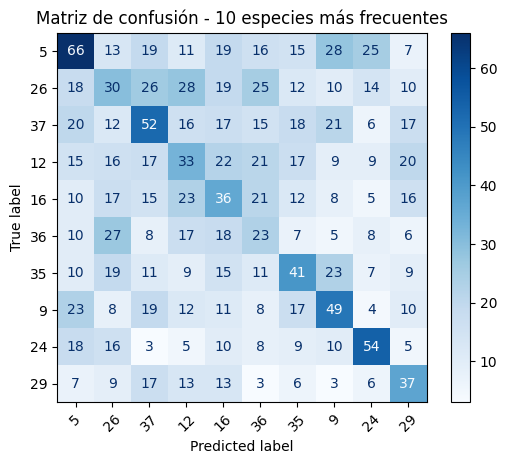

In [48]:
# 📊 Matriz de confusión para las 10 especies más frecuentes

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Seleccionar las 10 especies más comunes en el conjunto de test
top_species = yTest.value_counts().head(10).index

# Crear una máscara para filtrar solo esas especies
mask = yTest.isin(top_species)
yTest_top = yTest[mask]
yPred_top = yPred[mask]

# Calcular la matriz de confusión
cm = confusion_matrix(yTest_top, yPred_top, labels=top_species)

# Mostrar la matriz como gráfico
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_species)
disp.plot(cmap='Blues', xticks_rotation=45)

plt.title("Matriz de confusión - 10 especies más frecuentes")
plt.show()

Reporte de métricas

In [49]:
print(metrics.classification_report(yTest, yPred, digits=4))

              precision    recall  f1-score   support

           0     0.0747    0.0741    0.0744       243
           1     0.1978    0.2488    0.2204       213
           2     0.1237    0.1150    0.1192       200
           3     0.0900    0.1073    0.0979       177
           4     0.3182    0.3092    0.3136       249
           5     0.1667    0.1432    0.1540       461
           6     0.1357    0.1744    0.1527       172
           7     0.0737    0.0699    0.0717       229
           8     0.0870    0.0856    0.0863       187
           9     0.1561    0.1494    0.1526       328
          10     0.0718    0.0793    0.0754       164
          11     0.1105    0.1180    0.1141       178
          12     0.0833    0.0811    0.0822       407
          13     0.1164    0.1250    0.1205       176
          14     0.1511    0.1735    0.1615       196
          15     0.0352    0.0385    0.0367       182
          16     0.0957    0.0896    0.0925       402
          17     0.1509    

# XGBoost

Imports

In [50]:
import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

Eliminación de columnas y división de datos

In [51]:
dfXG = df.copy()

x = dfXG.drop('species',axis=1)
y = dfXG['species']
xTrain, xTest, yTrain, yTest = train_test_split(x, y, train_size=0.7, random_state=42, stratify=y)

In [52]:
# Separate features (x) and target (y) for SMOTE
x_smote = df.drop('species', axis=1)
y_smote = df['species']

# Apply SMOTE to the training data (assuming xTrain and yTrain are already defined)
smote = SMOTE(random_state=42)
xTrain, yTrain = smote.fit_resample(xTrain, yTrain)

print("Resampled dataset shape %s" % Counter(yTrain))

Resampled dataset shape Counter({11: 1074, 5: 1074, 9: 1074, 1: 1074, 27: 1074, 18: 1074, 8: 1074, 19: 1074, 13: 1074, 37: 1074, 34: 1074, 33: 1074, 3: 1074, 26: 1074, 6: 1074, 12: 1074, 17: 1074, 29: 1074, 14: 1074, 21: 1074, 31: 1074, 36: 1074, 23: 1074, 20: 1074, 10: 1074, 4: 1074, 28: 1074, 24: 1074, 15: 1074, 32: 1074, 16: 1074, 0: 1074, 2: 1074, 22: 1074, 25: 1074, 35: 1074, 7: 1074, 30: 1074})


Creamos y entrenamos el modelo

In [53]:
# Initialize and train the XGBoost Classifier
# We use XGBClassifier for classification problems.
# 'objective' specifies the loss function for binary classification.
# 'n_estimators' is the number of boosting rounds (trees).
# 'learning_rate' controls the step size shrinkage.

xgbst = xgb.XGBClassifier(objective='multi:softmax',
                          num_class=len(le.classes_), # Specify the number of classes
                          n_estimators=100,
                          learning_rate=0.1,
                          random_state=42)

xgbst.fit(xTrain, yTrain)

# Make predictions on the test set
yPred = xgbst.predict(xTest)

# Evaluate the model's performance
print("Accuracy:", metrics.accuracy_score(yTest, yPred))
print("Precision:", metrics.precision_score(yTest, yPred, average='weighted'))
print("F1 Score (macro avg):", metrics.f1_score(yTest, yPred, average='macro'))

Accuracy: 0.12492033142128744
Precision: 0.12348279107498399
F1 Score (macro avg): 0.12616523448186232


In [54]:
probabilidad = xgbst.predict_proba(xTest)

# Obtener las especies con mayor probabilidad para cada registro de test
top_3_species_indices = np.argsort(-probabilidad, axis=1)[:, :3]
top_10_species_indices = np.argsort(-probabilidad, axis=1)[:, :10]

# Mapear los índices a los nombres de las especies y obtener las probabilidades
top_3_species_names = xgbst.classes_[top_3_species_indices]
top_10_species_names = xgbst.classes_[top_10_species_indices]
top_3_probabilities = -np.sort(-probabilidad, axis=1)[:, :3]
top_10_probabilities = -np.sort(-probabilidad, axis=1)[:, :10]
acc1 = 0
acc3 = 0
acc10 = 0
sum1 = 0
sum3 = 0
sum10 = 0

for i in range(len(xTest)):
    if yTest.values[i] in top_10_species_names[i]:
        sum10 += 1
        if yTest.values[i] in top_3_species_names[i]:
            sum3 += 1
            if yTest.values[i] == yPred[i]:
                sum1 += 1

acc1 = sum1 / len(xTest)
acc3 = sum3 / len(xTest)
acc10 = sum10 / len(xTest)

print("TOP-K ACCURACY")
print("Top-1: ", acc1)
print("Top-3: ", acc3)
print("Top-10: ", acc10)

TOP-K ACCURACY
Top-1:  0.12492033142128744
Top-3:  0.26811132356065437
Top-10:  0.5718079456129169


## Matriz de confusión

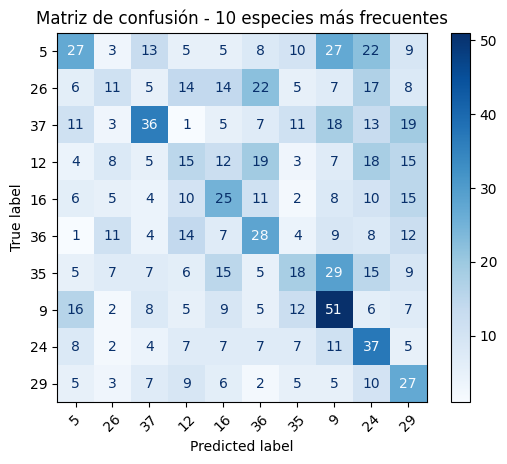

In [55]:
# 📊 Matriz de confusión para las 10 especies más frecuentes

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Seleccionar las 10 especies más comunes en el conjunto de test
yTest = pd.Series(yTest)
top_species = yTest.value_counts().head(10).index

# Crear una máscara para filtrar solo esas especies
mask = yTest.isin(top_species)
yTest_top = yTest[mask]
yPred_top = yPred[mask]

# Calcular la matriz de confusión
cm = confusion_matrix(yTest_top, yPred_top, labels=top_species)

# Mostrar la matriz como gráfico
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_species)
disp.plot(cmap='Blues', xticks_rotation=45)

plt.title("Matriz de confusión - 10 especies más frecuentes")
plt.show()